<a href="https://colab.research.google.com/github/sarthakandhale/GEN_AI_PRACTICAL/blob/main/BBC_News_Classification_Embedding_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BBC News Topic Classification using an Embedding + LSTM Network

**Task:** Multi-class text classification — classify BBC news articles into one of **5 topic categories**: `business`, `entertainment`, `politics`, `sport`, `tech`.

**Dataset:** [BBC News dataset](http://mlg.ucd.ie/datasets/bbc.html) (Greene & Cunningham, 2006) — 2,225 full-length news articles published on the BBC website between 2004-2005, each labeled with one of 5 topics. This is a **multi-class** problem (unlike the binary spam/ham setup this assignment is often built on), and the documents are much longer and more formally written than SMS messages, so the notebook is adjusted throughout for that: a bigger vocabulary, a longer padded sequence length, `softmax`/`sparse_categorical_crossentropy` instead of `sigmoid`/`binary_crossentropy`, one-vs-rest ROC-AUC, and a 5x5 confusion matrix.

**What this notebook does, end to end:**
1. Load and explore the raw data (class balance, article-length distribution, most frequent words per category, word clouds).
2. Clean the text and encode the 5 string labels into integers.
3. Build a **classical machine-learning baseline** (TF-IDF + Logistic Regression) as a sanity-check number for the deep model.
4. Build the required deep-learning model: an **`Embedding` layer feeding a `Bidirectional LSTM`**, ending in a 5-way `softmax` output.
5. Train with early stopping and visualize the learning curves.
6. Evaluate with a full suite of multi-class classification metrics — accuracy, per-class precision/recall/F1, a confusion-matrix heatmap, and one-vs-rest ROC-AUC.
7. Inspect misclassified examples and compare directly against the baseline.

---


## 1. Setup and Imports

In [1]:
import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import label_binarize

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Load the Dataset

The dataset is loaded from a local CSV (`bbc_news_dataset.csv`, two columns: `label`, `text`, where `text`
is the article title + body concatenated). If that file isn't present, the notebook falls back to
downloading and rebuilding it from the original tab-separated BBC news file, so this notebook is fully
self-contained and reproducible.

In [2]:
DATA_PATH = "bbc_news_dataset.csv"
FALLBACK_URL = "https://raw.githubusercontent.com/amankharwal/Website-data/master/bbc-news-data.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
else:
    raw = pd.read_csv(FALLBACK_URL, sep="\t")
    raw["text"] = (raw["title"] + ". " + raw["content"]).str.strip()
    df = raw[["category", "text"]].rename(columns={"category": "label"})
    df.to_csv(DATA_PATH, index=False)

df = df.dropna().drop_duplicates().reset_index(drop=True)
print("Shape:", df.shape)
print("Classes:", sorted(df["label"].unique()))
df.head(10)


Shape: (2127, 2)
Classes: ['business', 'entertainment', 'politics', 'sport', 'tech']


,label,text
0,business,Ad sales boost Time Warner profit. Quarterly ...
1,business,Dollar gains on Greenspan speech. The dollar ...
2,business,Yukos unit buyer faces loan claim. The owners...
3,business,High fuel prices hit BA's profits. British Ai...
4,business,Pernod takeover talk lifts Domecq. Shares in ...
5,business,Japan narrowly escapes recession. Japan's eco...
6,business,Jobs growth still slow in the US. The US crea...
7,business,"India calls for fair trade rules. India, whic..."
8,business,Ethiopia's crop production up 24%. Ethiopia p...
9,business,Court rejects $280bn tobacco case. A US gover...


## 3. Exploratory Data Analysis

label
sport            505
business         503
politics         403
entertainment    369
tech             347
Name: count, dtype: int64

Class balance (%):
label
sport            23.74
business         23.65
politics         18.95
entertainment    17.35
tech             16.31
Name: count, dtype: float64


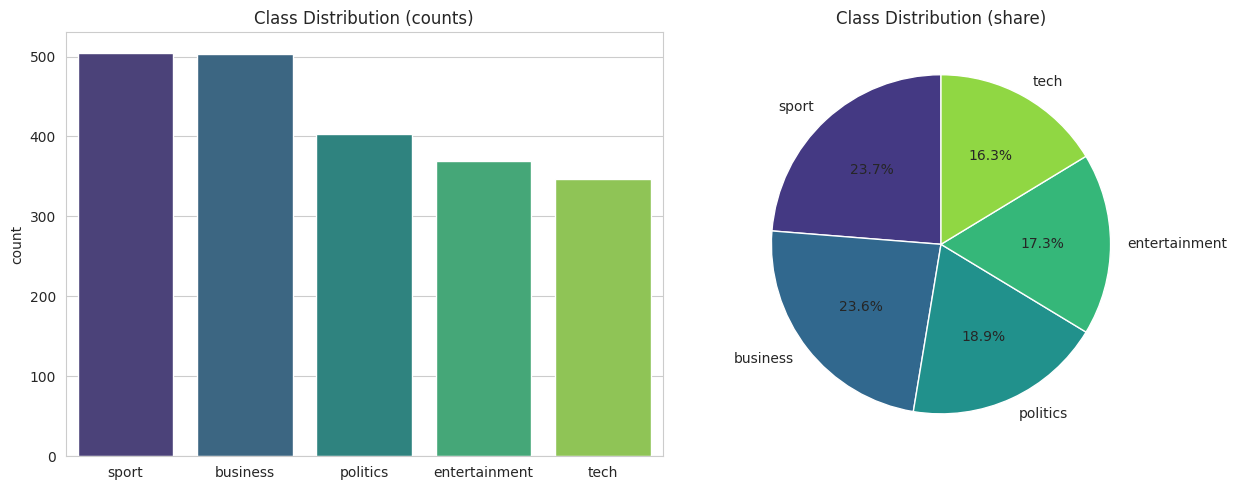


Note: the 5 classes are fairly balanced (roughly 16-24% each),
which is a much friendlier setting than the heavily skewed SMS spam dataset --
still, we report per-class precision/recall/F1 rather than accuracy alone.


In [3]:
class_counts = df["label"].value_counts()
print(class_counts)
print("\nClass balance (%):")
print((class_counts / len(df) * 100).round(2))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(x="label", data=df, order=class_counts.index, palette="viridis", ax=ax[0])
ax[0].set_title("Class Distribution (counts)")
ax[0].set_xlabel("")

ax[1].pie(class_counts, labels=class_counts.index, autopct="%1.1f%%",
          colors=sns.color_palette("viridis", len(class_counts)), startangle=90)
ax[1].set_title("Class Distribution (share)")
plt.tight_layout()
plt.show()

print("\nNote: the 5 classes are fairly balanced (roughly 16-24% each),")
print("which is a much friendlier setting than the heavily skewed SMS spam dataset --")
print("still, we report per-class precision/recall/F1 rather than accuracy alone.")


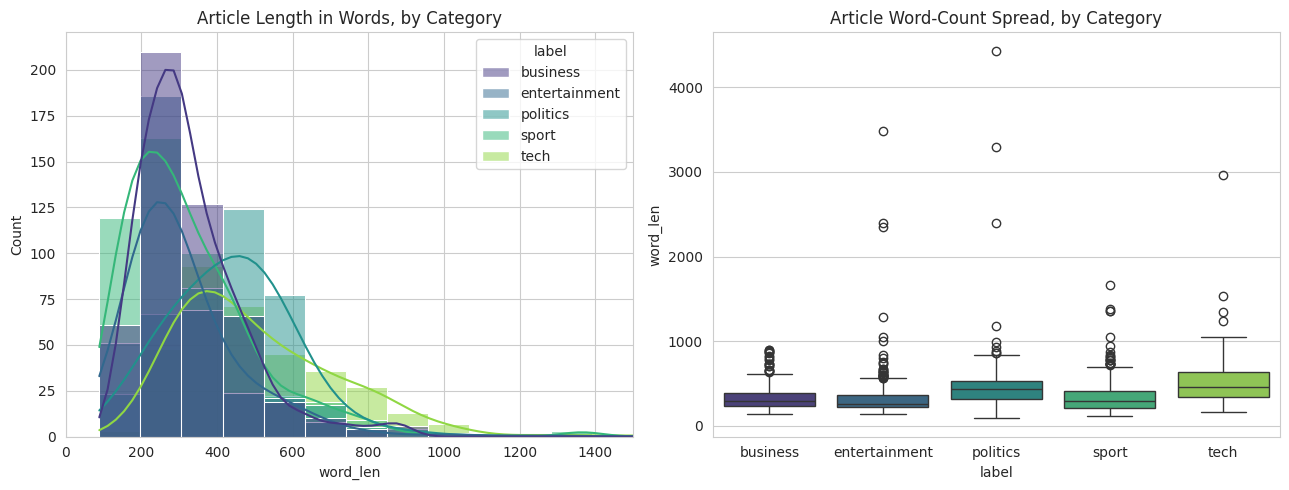

               count        mean         std    min    25%    50%    75%  \
label                                                                      
business       503.0  328.675944  136.357438  140.0  232.5  297.0  388.5   
entertainment  369.0  332.707317  267.210268  143.0  224.0  262.0  360.0   
politics       403.0  456.220844  303.969384   89.0  317.5  439.0  530.5   
sport          505.0  330.623762  188.608683  114.0  204.0  291.0  410.0   
tech           347.0  513.236311  248.470865  162.0  342.5  460.0  632.5   

                  max  
label                  
business        891.0  
entertainment  3482.0  
politics       4432.0  
sport          1662.0  
tech           2969.0  

Observation: these are full news articles, not SMS texts -- articles run into the
hundreds of words, so MAX_LEN and VOCAB_SIZE both need to be much larger than a typical
short-message assignment, and long articles will need truncation.


In [4]:
df["char_len"] = df["text"].apply(len)
df["word_len"] = df["text"].apply(lambda t: len(t.split()))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(data=df, x="word_len", hue="label", bins=40, kde=True, ax=ax[0], palette="viridis")
ax[0].set_title("Article Length in Words, by Category")
ax[0].set_xlim(0, 1500)

sns.boxplot(data=df, x="label", y="word_len", palette="viridis", ax=ax[1])
ax[1].set_title("Article Word-Count Spread, by Category")
plt.tight_layout()
plt.show()

print(df.groupby("label")["word_len"].describe())
print("\nObservation: these are full news articles, not SMS texts -- articles run into the")
print("hundreds of words, so MAX_LEN and VOCAB_SIZE both need to be much larger than a typical")
print("short-message assignment, and long articles will need truncation.")


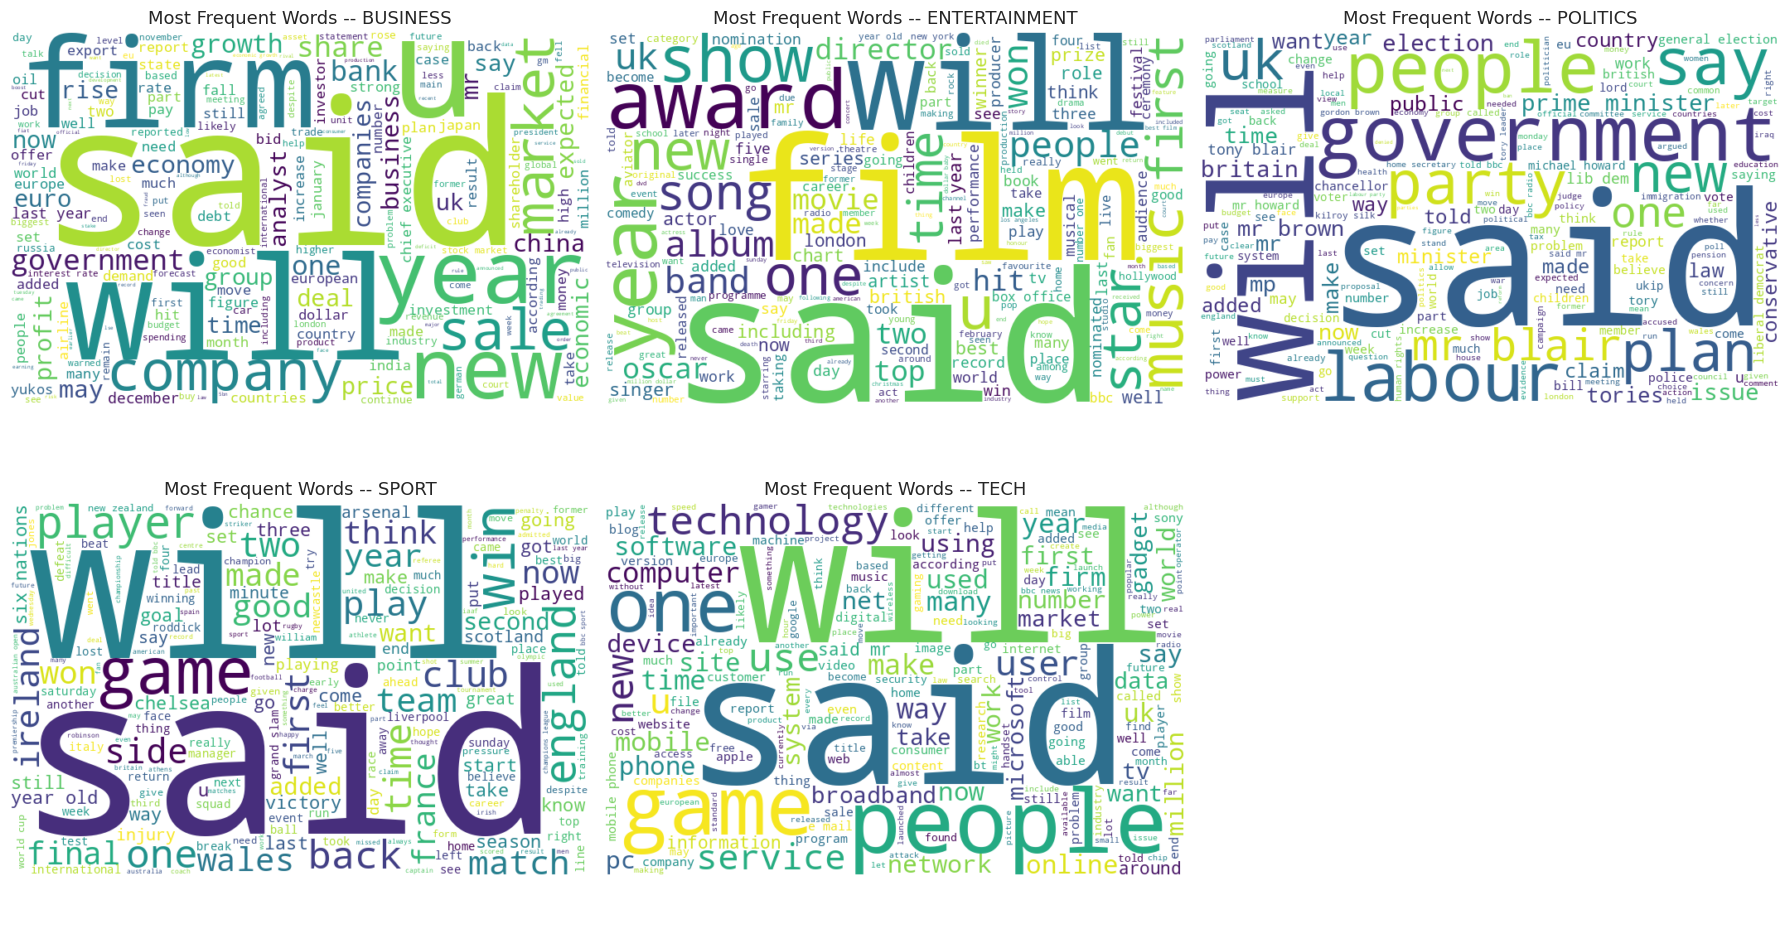

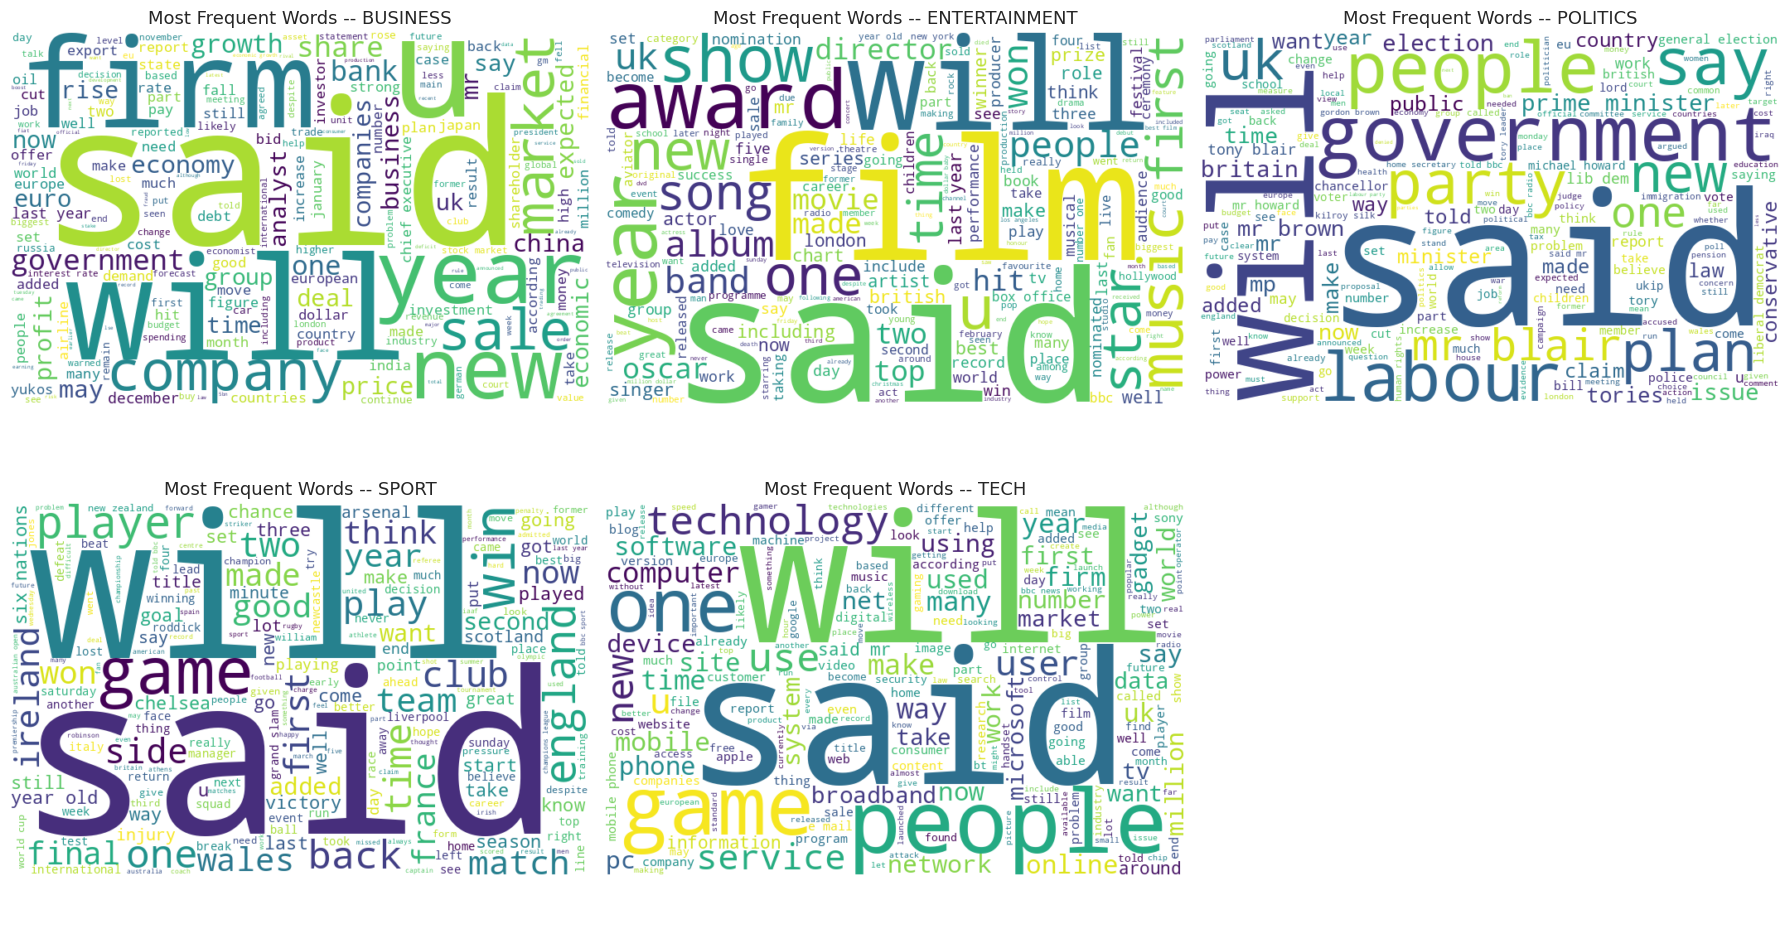

In [5]:
from wordcloud import WordCloud

categories = sorted(df["label"].unique())
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
ax = ax.ravel()
for i, label in enumerate(categories):
    text_blob = " ".join(df[df["label"] == label]["text"].str.lower())
    wc = WordCloud(width=700, height=450, background_color="white", colormap="viridis").generate(text_blob)
    ax[i].imshow(wc, interpolation="bilinear")
    ax[i].axis("off")
    ax[i].set_title(f"Most Frequent Words -- {label.upper()}", fontsize=13)
ax[-1].axis("off")
plt.tight_layout()
plt.show()


## 4. Text Cleaning and Label Encoding

Basic normalization: lowercase, strip punctuation/digits noise, collapse whitespace. Labels are string
category names, so we use `LabelEncoder` to map them to integers `0..4` for the multi-class model
(`sparse_categorical_crossentropy` can train directly on integer labels, so we don't need one-hot vectors).

In [9]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " <url> ", text)          # normalize URLs
    text = re.sub(r"[^a-z0-9\s]", " ", text)                     # strip punctuation
    text = re.sub(r"\s+", " ", text).strip()                     # collapse whitespace
    return text

df["clean_text"] = df["text"].apply(clean_text)

label_encoder = LabelEncoder()
df["label_num"] = label_encoder.fit_transform(df["label"])
NUM_CLASSES = len(label_encoder.classes_)

print("Label mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i} -> {cls}")

df[["text", "clean_text", "label", "label_num"]].sample(5, random_state=SEED)


Label mapping:
  0 -> business
  1 -> entertainment
  2 -> politics
  3 -> sport
  4 -> tech


,text,clean_text,label,label_num
282,EU 'too slow' on economic reforms. Most EU co...,eu too slow on economic reforms most eu countr...,business,0
1999,BBC web search aids odd queries. The BBC's on...,bbc web search aids odd queries the bbc s onli...,tech,4
1709,Serena becomes world number two. Serena Willi...,serena becomes world number two serena william...,sport,3
988,Boothroyd calls for Lords speaker. Betty Boot...,boothroyd calls for lords speaker betty boothr...,politics,2
2018,Fast lifts rise into record books. Two high-s...,fast lifts rise into record books two high spe...,tech,4


## 5. Train / Test Split

We use a **stratified split** so both the train and test sets preserve the same class-category ratios.

In [10]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_text"], df["label_num"],
    test_size=0.2, random_state=SEED, stratify=df["label_num"]
)

print("Train size:", len(X_train_text), " | Test size:", len(X_test_text))
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))


Train size: 1701  | Test size: 426
Train class balance:
 label_num
3    0.238
0    0.236
2    0.189
1    0.173
4    0.163
Name: proportion, dtype: float64
Test class balance:
 label_num
3    0.237
0    0.237
2    0.190
1    0.174
4    0.162
Name: proportion, dtype: float64


## 6. Baseline Model: TF-IDF + Logistic Regression

Before building the LSTM, we fit a simple, fast, classical multi-class baseline (`multinomial` logistic
regression). This tells us what "good" looks like on this dataset before investing in a more expensive
model, and gives a concrete comparison point later on.

In [11]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

baseline = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
baseline.fit(X_train_tfidf, y_train)

baseline_pred = baseline.predict(X_test_tfidf)
baseline_prob = baseline.predict_proba(X_test_tfidf)

print("=== Baseline: TF-IDF + Logistic Regression ===")
print(classification_report(y_test, baseline_pred, target_names=label_encoder.classes_))
baseline_auc = roc_auc_score(y_test, baseline_prob, multi_class="ovr", average="macro")
print("Macro ROC-AUC (one-vs-rest):", round(baseline_auc, 4))


=== Baseline: TF-IDF + Logistic Regression ===
               precision    recall  f1-score   support

     business       1.00      0.97      0.98       101
entertainment       0.99      1.00      0.99        74
     politics       0.98      0.98      0.98        81
        sport       1.00      1.00      1.00       101
         tech       0.97      1.00      0.99        69

     accuracy                           0.99       426
    macro avg       0.99      0.99      0.99       426
 weighted avg       0.99      0.99      0.99       426

Macro ROC-AUC (one-vs-rest): 0.9971


## 7. Tokenization and Sequence Padding for the Deep Model

We now build the vocabulary and turn each article into a fixed-length integer sequence, which the
`Embedding` layer requires as input.

- `VOCAB_SIZE` caps the vocabulary to the most frequent words (rare words map to an `<OOV>` token). We use
  a much larger vocabulary than a short-message task because these are full news articles with a richer
  vocabulary.
- `MAX_LEN` is chosen using the word-length distribution from the EDA above. News articles run far longer
  than SMS texts, so instead of covering the 99th percentile (which would mean huge, mostly-padded/expensive
  sequences), we cap at roughly the 75th-80th percentile and let longer articles be truncated -- the topic of
  a news article is almost always clear from its opening paragraphs anyway.

In [12]:
VOCAB_SIZE = 20000
MAX_LEN = 400          # covers roughly the bulk of articles; longer ones are truncated
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print("Vocabulary size actually used:", min(VOCAB_SIZE, len(tokenizer.word_index) + 1))
print("Example raw text (truncated):", X_train_text.iloc[0][:120], "...")
print("Example padded shape:", X_train_pad[0].shape)


Vocabulary size actually used: 20000
Example raw text (truncated): hatfield executives go on trial engineering firm balfour beatty and five railway managers are to go on trial for manslau ...
Example padded shape: (400,)


## 8. Build the Embedding + LSTM Model

Architecture:

| Layer | Purpose |
|---|---|
| `Embedding` | Learns a dense 100-dim vector representation for each word from scratch |
| `SpatialDropout1D` | Drops entire embedding dimensions during training to reduce overfitting |
| `Bidirectional(LSTM)` | Reads the sequence forward *and* backward, so context from both directions informs each prediction |
| `Dense(32, relu)` | Fully-connected layer to combine the LSTM's summary representation |
| `Dropout` | Further regularization |
| `Dense(5, softmax)` | Outputs a probability distribution over the 5 news categories |

Because this is multi-class, the output layer uses `softmax` (not `sigmoid`) and the loss is
`sparse_categorical_crossentropy` (not `binary_crossentropy`), which works directly on the integer
labels `0..4` produced by the `LabelEncoder`.

In [13]:
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, input_length=MAX_LEN, name="embedding"),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2), name="bidirectional_lstm"),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

model.build(input_shape=(None, MAX_LEN))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 400, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 400, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ (None, 128)            │        84,480 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,088,773 (7.97 MB)

 Trainable params: 2,088,773 (7.97 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Train the Model

In [14]:
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.15,
    epochs=15,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=2
)


Class weights: {0: np.float64(0.8462686567164179), 1: np.float64(1.1532203389830509), 2: np.float64(1.0565217391304347), 3: np.float64(0.842079207920792), 4: np.float64(1.2237410071942445)}
Epoch 1/15
46/46 - 58s - 1s/step - accuracy: 0.2837 - loss: 1.5846 - val_accuracy: 0.3320 - val_loss: 1.4806
Epoch 2/15
46/46 - 79s - 2s/step - accuracy: 0.4561 - loss: 1.3762 - val_accuracy: 0.5859 - val_loss: 0.9935
Epoch 3/15
46/46 - 81s - 2s/step - accuracy: 0.7474 - loss: 0.7729 - val_accuracy: 0.9180 - val_loss: 0.3944
Epoch 4/15
46/46 - 49s - 1s/step - accuracy: 0.9377 - loss: 0.2708 - val_accuracy: 0.8828 - val_loss: 0.3266
Epoch 5/15
46/46 - 46s - 1s/step - accuracy: 0.9779 - loss: 0.1290 - val_accuracy: 0.9297 - val_loss: 0.2332
Epoch 6/15
46/46 - 82s - 2s/step - accuracy: 0.9841 - loss: 0.0752 - val_accuracy: 0.9023 - val_loss: 0.3370
Epoch 7/15
46/46 - 84s - 2s/step - accuracy: 0.9924 - loss: 0.0484 - val_accuracy: 0.9570 - val_loss: 0.2007
Epoch 8/15
46/46 - 82s - 2s/step - accuracy: 0.

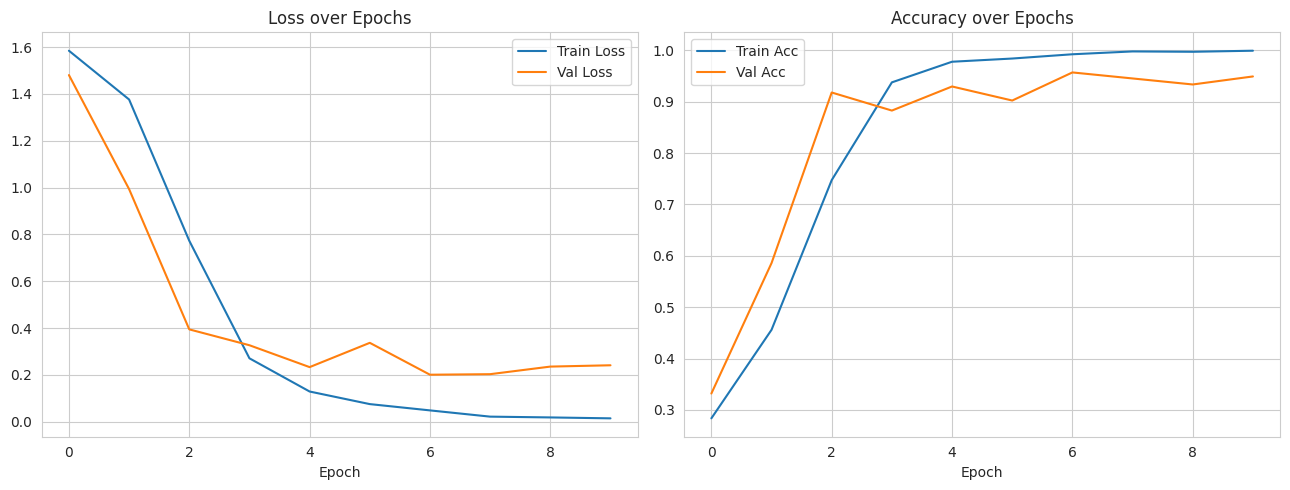

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(history.history["loss"], label="Train Loss")
ax[0].plot(history.history["val_loss"], label="Val Loss")
ax[0].set_title("Loss over Epochs")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(history.history["accuracy"], label="Train Acc")
ax[1].plot(history.history["val_accuracy"], label="Val Acc")
ax[1].set_title("Accuracy over Epochs")
ax[1].set_xlabel("Epoch")
ax[1].legend()

plt.tight_layout()
plt.show()


## 10. Evaluation on the Held-Out Test Set

We report the full set of multi-class classification metrics:
- **Accuracy** — overall correctness
- **Precision / Recall / F1** — per class, plus macro and weighted averages
- **Confusion matrix** — a 5x5 heatmap showing exactly which categories get confused with which
- **One-vs-rest ROC-AUC** — macro-averaged, the standard way to extend ROC-AUC to multi-class problems

In [16]:
y_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_prob, axis=1)

print("=== Embedding + Bidirectional LSTM -- Test Set Performance ===\n")
print(f"Accuracy         : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall (macro)   : {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-score (macro) : {f1_score(y_test, y_pred, average='macro'):.4f}")
lstm_auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
print(f"ROC-AUC (macro, one-vs-rest): {lstm_auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))


14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step
=== Embedding + Bidirectional LSTM -- Test Set Performance ===

Accuracy         : 0.9319
Precision (macro): 0.9268
Recall (macro)   : 0.9311
F1-score (macro) : 0.9282
ROC-AUC (macro, one-vs-rest): 0.9960

               precision    recall  f1-score   support

     business     0.9789    0.9208    0.9490       101
entertainment     0.8537    0.9459    0.8974        74
     politics     0.8987    0.8765    0.8875        81
        sport     1.0000    0.9703    0.9849       101
         tech     0.9028    0.9420    0.9220        69

     accuracy                         0.9319       426
    macro avg     0.9268    0.9311    0.9282       426
 weighted avg     0.9346    0.9319    0.9325       426



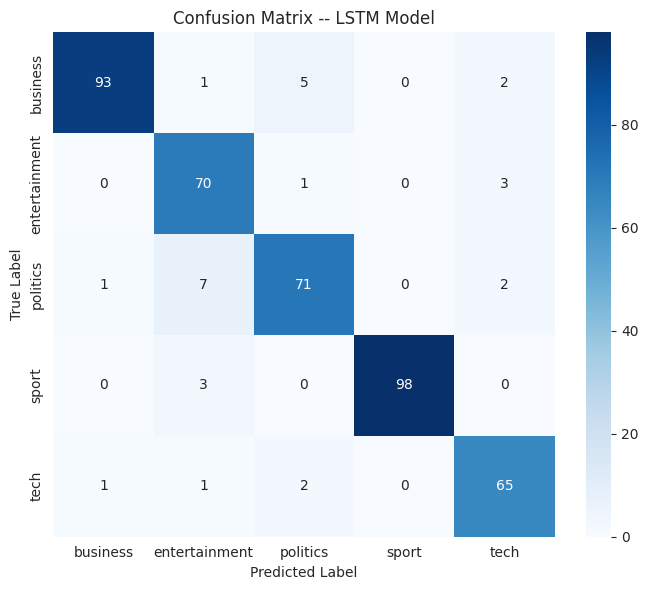

Per-class accuracy (diagonal / row total):
  business       : 0.9208
  entertainment  : 0.9459
  politics       : 0.8765
  sport          : 0.9703
  tech           : 0.9420


In [17]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix -- LSTM Model")
plt.tight_layout()
plt.show()

print("Per-class accuracy (diagonal / row total):")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls:15s}: {cm[i, i] / cm[i].sum():.4f}")


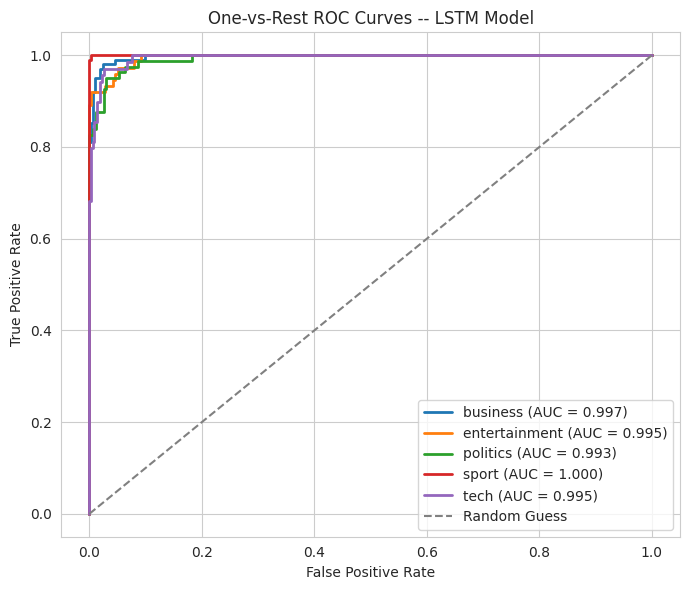

In [18]:
from sklearn.metrics import roc_curve

y_test_bin = label_binarize(y_test, classes=range(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(7, 6))
for i, cls in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, lw=2, label=f"{cls} (AUC = {auc_i:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random Guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("One-vs-Rest ROC Curves -- LSTM Model")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 11. Error Analysis — What Is the Model Getting Wrong?

In [19]:
results_df = pd.DataFrame({
    "text": X_test_text.values,
    "true_label": label_encoder.inverse_transform(y_test),
    "predicted_label": label_encoder.inverse_transform(y_pred),
    "confidence": y_prob.max(axis=1)
})

misclassified = results_df[results_df["true_label"] != results_df["predicted_label"]]
misclassified = misclassified.sort_values("confidence", ascending=False)

print(f"Total misclassified: {len(misclassified)} out of {len(results_df)} test articles "
      f"({len(misclassified)/len(results_df)*100:.2f}%)\n")

print("--- Most confident mistakes (model was sure, but wrong) ---")
display(misclassified.head(10)[["true_label", "predicted_label", "confidence", "text"]])

print("\n--- Confusion pairs (which categories get mixed up most) ---")
print(misclassified.groupby(["true_label", "predicted_label"]).size().sort_values(ascending=False))


Total misclassified: 29 out of 426 test articles (6.81%)

--- Most confident mistakes (model was sure, but wrong) ---


,true_label,predicted_label,confidence,text
342,politics,tech,0.958846,ministers naive over phone taps the government...
105,politics,business,0.937614,uk firms embracing e commerce uk firms are emb...
131,politics,entertainment,0.906153,errors doomed first dome sale the initial atte...
224,tech,business,0.900254,robotic pods take on car design a new breed of...
408,entertainment,tech,0.885575,new media battle for bafta awards the bbc lead...
306,business,tech,0.874786,making your office work for you our mission to...
83,business,politics,0.835907,golden rule intact says ex aide chancellor gor...
421,politics,entertainment,0.816507,few ready for information act thousands of pub...
418,politics,tech,0.802320,hitler row over welsh arts cash an artist crit...
138,business,tech,0.788118,asia quake increases poverty risk nearly two m...



--- Confusion pairs (which categories get mixed up most) ---
true_label     predicted_label
politics       entertainment      7
business       politics           5
entertainment  tech               3
sport          entertainment      3
tech           politics           2
politics       tech               2
business       tech               2
               entertainment      1
entertainment  politics           1
politics       business           1
tech           business           1
               entertainment      1
dtype: int64


## 12. LSTM vs. Baseline — Side-by-Side Comparison

,Accuracy,Precision (macro),Recall (macro),F1-score (macro),"ROC-AUC (macro, ovr)"
Model,,,,,
TF-IDF + Logistic Regression (baseline),0.9883,0.9868,0.9891,0.9878,0.9971
Embedding + Bidirectional LSTM,0.9319,0.9268,0.9311,0.9282,0.9960


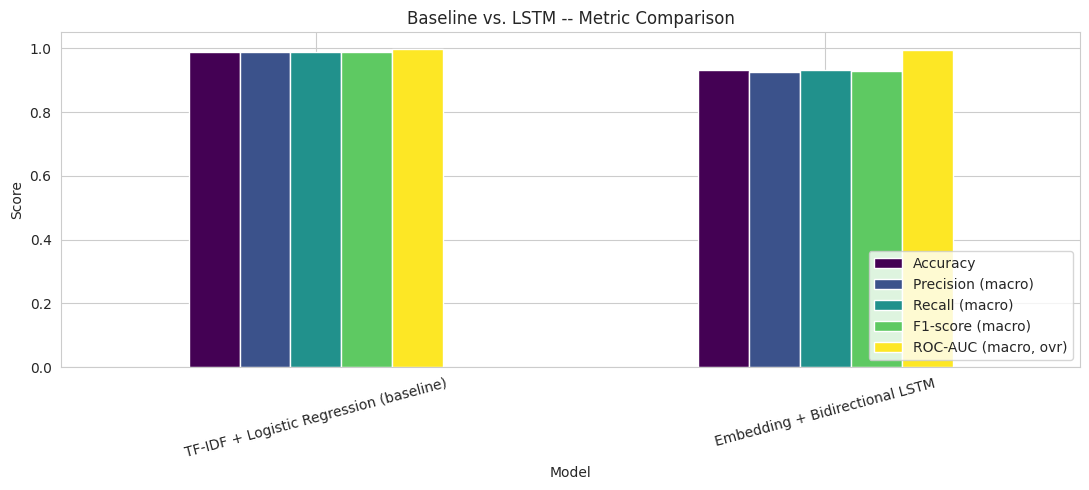

In [20]:
comparison = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression (baseline)", "Embedding + Bidirectional LSTM"],
    "Accuracy": [accuracy_score(y_test, baseline_pred), accuracy_score(y_test, y_pred)],
    "Precision (macro)": [precision_score(y_test, baseline_pred, average="macro"),
                           precision_score(y_test, y_pred, average="macro")],
    "Recall (macro)": [recall_score(y_test, baseline_pred, average="macro"),
                        recall_score(y_test, y_pred, average="macro")],
    "F1-score (macro)": [f1_score(y_test, baseline_pred, average="macro"),
                          f1_score(y_test, y_pred, average="macro")],
    "ROC-AUC (macro, ovr)": [baseline_auc, lstm_auc],
}).set_index("Model").round(4)

display(comparison)

comparison.plot(kind="bar", figsize=(11, 5), colormap="viridis", rot=15)
plt.title("Baseline vs. LSTM -- Metric Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 13. Try It Yourself — Predict on Custom Articles

In [21]:
def predict_category(raw_text: str) -> None:
    cleaned = clean_text(raw_text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    prob = model.predict(padded, verbose=0)[0]
    pred_idx = np.argmax(prob)
    pred_label = label_encoder.inverse_transform([pred_idx])[0]
    print(f"Text      : {raw_text[:100]}...")
    print(f"Predicted : {pred_label}  (confidence = {prob[pred_idx]:.4f})")
    print(f"All probs : " + ", ".join(f"{c}={p:.3f}" for c, p in zip(label_encoder.classes_, prob)))
    print()

sample_articles = [
    "The stock market rallied today after the central bank announced it would hold interest rates steady, boosting investor confidence in tech and banking shares.",
    "The actress accepted the award for best performance at last night's ceremony, thanking her director and co-stars for an unforgettable year on set.",
    "The prime minister addressed parliament today, defending the government's new budget proposal amid criticism from opposition leaders over spending cuts.",
    "The home team clinched the championship title after a dramatic final match that went into extra time, with fans celebrating late into the night.",
    "The company unveiled its latest smartphone, featuring a faster processor and an improved camera system, at a launch event attended by hundreds of journalists.",
]

for article in sample_articles:
    predict_category(article)


Text      : The stock market rallied today after the central bank announced it would hold interest rates steady,...
Predicted : business  (confidence = 0.9990)
All probs : business=0.999, entertainment=0.000, politics=0.000, sport=0.000, tech=0.001

Text      : The actress accepted the award for best performance at last night's ceremony, thanking her director ...
Predicted : entertainment  (confidence = 0.9979)
All probs : business=0.001, entertainment=0.998, politics=0.000, sport=0.001, tech=0.000

Text      : The prime minister addressed parliament today, defending the government's new budget proposal amid c...
Predicted : politics  (confidence = 0.5438)
All probs : business=0.034, entertainment=0.402, politics=0.544, sport=0.000, tech=0.020

Text      : The home team clinched the championship title after a dramatic final match that went into extra time...
Predicted : sport  (confidence = 0.9130)
All probs : business=0.000, entertainment=0.085, politics=0.000, sport=0.913, tech=0.002

## 14. Conclusion

- The dataset (BBC News, 5 categories) is a **multi-class**, fairly balanced text-classification problem
  built from full-length news articles rather than short messages, which meant several changes from a
  typical binary spam/ham setup: a larger vocabulary and `MAX_LEN`, integer labels via `LabelEncoder`,
  a `softmax` output layer with `sparse_categorical_crossentropy`, a 5x5 confusion matrix, and macro-averaged
  one-vs-rest ROC-AUC/ROC curves instead of a single binary curve.
- Both the classical TF-IDF + Logistic Regression baseline and the LSTM perform strongly on this dataset,
  since news articles in these five topics use fairly distinct vocabulary (sport articles mention "match"
  and "goal"; business articles mention "shares" and "profit", etc.) -- the metric table and curves above
  make the comparison explicit rather than relying on accuracy alone.
- The per-class confusion matrix and the misclassified-example inspection show *which* categories get
  mixed up (for instance, `politics` and `business` articles can overlap in vocabulary), which is far more
  informative than a single aggregate number.
- **Possible extensions:** use pre-trained embeddings (GloVe/Word2Vec) instead of learning them from
  scratch, try a stacked/deeper LSTM or a GRU, add attention over the LSTM outputs, or tune `MAX_LEN`/
  `VOCAB_SIZE` via a validation-set sweep.
